In [2]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/2-68/PattRecog/FinalProject2

# ทำครั้งเดียวพอ
# !git clone https://github.com/maty-bohacek/spoter

!pip install --upgrade pip
!pip install pandas tqdm matplotlib torch torchvision scikit-learn opencv-python

Mounted at /content/drive
/content/drive/MyDrive/2-68/PattRecog/FinalProject2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 84.0 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [3]:
%cd /content/drive/MyDrive/2-68/PattRecog/FinalProject2

/content/drive/MyDrive/2-68/PattRecog/FinalProject2


In [4]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/2-68/PattRecog/FinalProject2/spoter/datasets/train_normalized.csv")

labels = df.iloc[:, -1]

print("min:", labels.min())
print("max:", labels.max())
print("num unique:", len(labels.unique()))

min: 0
max: 183
num unique: 184


In [ ]:
!python spoter/train.py \
  --validation_set split-from-train

/content/drive/MyDrive/2-68/PattRecog/FinalProject2/spoter/spoter/spoter_model.py:70: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  self.encoder = nn.TransformerEncoder(
Starting lsa_64_spoter...


[1] TRAIN  loss: 5.301557050845869 acc: 0.004947229551451188
[1] VALIDATION  acc: 0.00922266139657444

[2] TRAIN  loss: 4.984982481732532 acc: 0.020448548812664908
[2] VALIDATION  acc: 0.05138339920948617

[3] TRAIN  loss: 4.353153911696889 acc: 0.06926121372031663
[3] VALIDATION  acc: 0.12911725955204217

[4] TRAIN  loss: 3.850236378118671 acc: 0.15468337730870713
[4] VALIDATION  acc: 0.22134387351778656

[5] TRAIN  loss: 3.3866353785535592 acc: 0.2631926121372032
[5] VALIDATION  acc: 0.31488801054018445

[6] TRAIN  loss: 2.924757529217209 acc: 0.35883905013192613
[6] VALIDATION  acc: 0.3241106719367589

[7] TRAIN  loss: 2.5240431528115805 acc: 0.4561345646437995
[7] VALIDATION  acc: 0.46903820816864294

[8]

In [ ]:
!python spoter/train.py \
  --validation_set split-from-train

/content/drive/MyDrive/2-68/PattRecog/FinalProject2/spoter/spoter/spoter_model.py:70: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  self.encoder = nn.TransformerEncoder(
Starting lsa_64_spoter...



Testing checkpointed models starting...

Label accuracies statistics:
{89: 0.0, 61: 0.0, 150: 0.0, 110: 0.0, 56: 0.0, 174: 0.0, 69: 0.0, 82: 0.0, 116: 0.0, 43: 0.0, 28: 0.0, 134: 0.0, 87: 0.0, 80: 0.0, 173: 0.0, 143: 0.0, 162: 0.0, 60: 0.0, 147: 0.0, 35: 0.0, 33: 0.0, 111: 0.0, 97: 0.0, 148: 0.0, 68: 0.0, 112: 0.0, 94: 0.0, 84: 0.0, 54: 0.0, 182: 0.0, 125: 0.0, 183: 0.0, 158: 0.0, 74: 0.0, 124: 0.0, 73: 0.0, 176: 0.0, 27: 0.0, 128: 0.0, 169: 0.0, 39: 0.0, 159: 0.0, 130: 0.0, 126: 0.0, 117: 0.0, 49: 0.0, 40: 0.0, 38: 0.0, 170: 0.0, 175: 0.0, 140: 0.0, 151: 0.0, 93: 0.0, 25: 0.0, 105: 0.0, 163: 0.0, 75: 0.0, 7: 0.0, 161: 0.0, 62: 0.0, 181: 0.0, 95: 0.0, 104: 0.0, 138: 0.0, 144: 0.0, 4: 0.0, 67: 0.0, 101: 0.0, 

ดึงข้อมูลสำเร็จ! พบ TRAIN 100 epochs และ VALIDATION 100 epochs



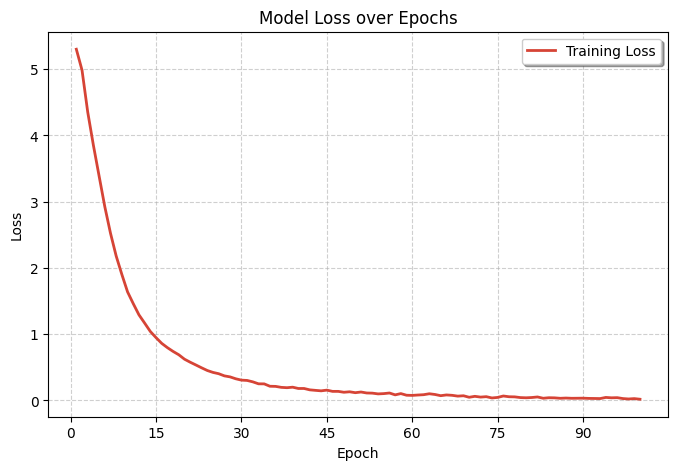

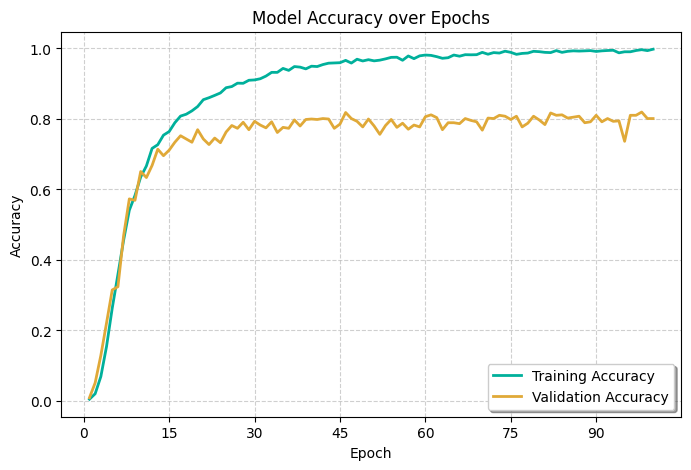

In [ ]:
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 🚨 อย่าลืมเช็ค Path และชื่อไฟล์ Log อีกรอบนะครับ
log_file_path = "/content/drive/MyDrive/2-68/PattRecog/FinalProject2/lsa_64_spoter_None.log"

losses = []
train_accs = []
val_accs = []

try:
    # 1. ดึงข้อมูลจากไฟล์ Log
    with open(log_file_path, "r", encoding="utf-8") as f:
        for line in f:
            if "TRAIN" in line and "loss:" in line:
                loss_match = re.search(r"loss:\s*([\d\.]+)", line)
                acc_match = re.search(r"acc:\s*([\d\.]+)", line)
                if loss_match and acc_match:
                    losses.append(float(loss_match.group(1)))
                    train_accs.append(float(acc_match.group(1)))

            elif "VALIDATION" in line and "acc:" in line:
                acc_match = re.search(r"acc:\s*([\d\.]+)", line)
                if acc_match:
                    val_accs.append(float(acc_match.group(1)))

    print(f"ดึงข้อมูลสำเร็จ! พบ TRAIN {len(losses)} epochs และ VALIDATION {len(val_accs)} epochs\n")

    # ==========================
    # กราฟที่ 1: Training Loss
    # ==========================
    fig1, ax1 = plt.subplots(figsize=(8, 5))

    ax1.plot(range(1, len(losses) + 1), losses, c="#D64436", label="Training Loss", linewidth=2)

    ax1.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax1.set(xlabel="Epoch", ylabel="Loss", title="Model Loss over Epochs")
    ax1.legend(loc="upper right", fancybox=True, shadow=True)
    ax1.grid(True, linestyle="--", alpha=0.6)

    # โชว์กราฟที่ 1
    plt.show()

    print("\n" + "="*50 + "\n") # ขีดเส้นคั่นระหว่าง 2 กราฟให้ดูง่ายๆ

    # ==========================
    # กราฟที่ 2: Training & Validation Accuracy
    # ==========================
    fig2, ax2 = plt.subplots(figsize=(8, 5))

    ax2.plot(range(1, len(train_accs) + 1), train_accs, c="#00B09B", label="Training Accuracy", linewidth=2)

    if len(val_accs) > 0:
        ax2.plot(range(1, len(val_accs) + 1), val_accs, c="#E0A938", label="Validation Accuracy", linewidth=2)

    ax2.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax2.set(xlabel="Epoch", ylabel="Accuracy", title="Model Accuracy over Epochs")
    ax2.legend(loc="lower right", fancybox=True, shadow=True)
    ax2.grid(True, linestyle="--", alpha=0.6)

    # โชว์กราฟที่ 2
    plt.show()

    # ถ้าต้องการเซฟกราฟทั้ง 2 รูปเก็บไว้ เอาคอมเมนต์ 2 บรรทัดล่างนี้ออกได้เลยครับ
    # fig1.savefig("loss_chart.png", bbox_inches='tight')
    # fig2.savefig("accuracy_chart.png", bbox_inches='tight')

except FileNotFoundError:
    print(f"❌ หาไฟล์ Log ไม่เจอครับ! ตรวจสอบว่าชื่อไฟล์และ Path ถูกต้องไหม ({log_file_path})")

ดึงข้อมูลสำเร็จ! พบ TRAIN 100 epochs และ VALIDATION 100 epochs


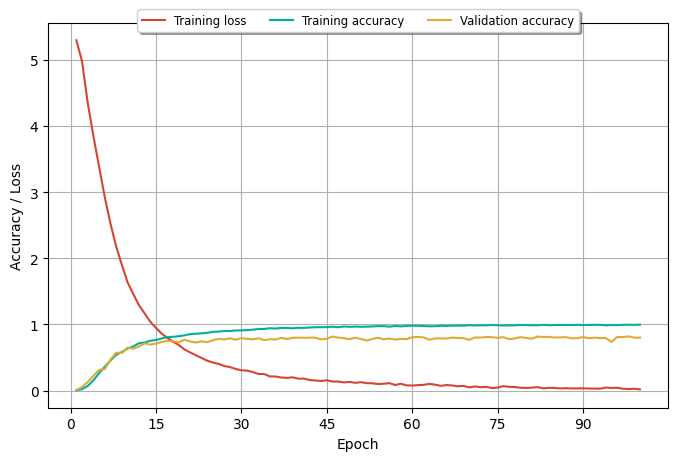


กราฟ Learning Rate (จะว่างเปล่าเพราะไม่ได้บันทึกค่า LR ลงใน Log):


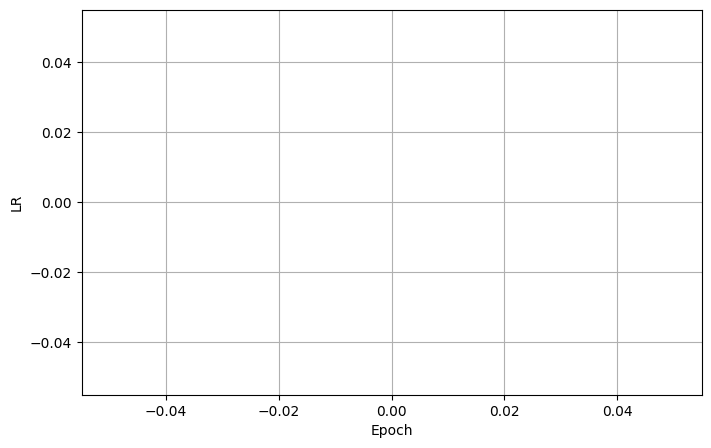

In [ ]:
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 🚨 อย่าลืมเปลี่ยนชื่อไฟล์ตรงนี้ให้ตรงกับไฟล์ Log ของคุณใน Drive นะครับ
log_file_path = "/content/drive/MyDrive/2-68/PattRecog/FinalProject2/lsa_64_spoter_None.log"

losses = []
train_accs = []
val_accs = []

try:
    # 1. อ่านข้อมูลจากไฟล์ Log
    with open(log_file_path, "r", encoding="utf-8") as f:
        for line in f:
            if "TRAIN" in line and "loss:" in line:
                loss_match = re.search(r"loss:\s*([\d\.]+)", line)
                acc_match = re.search(r"acc:\s*([\d\.]+)", line)
                if loss_match and acc_match:
                    losses.append(float(loss_match.group(1)))
                    train_accs.append(float(acc_match.group(1)))

            elif "VALIDATION" in line and "acc:" in line:
                acc_match = re.search(r"acc:\s*([\d\.]+)", line)
                if acc_match:
                    val_accs.append(float(acc_match.group(1)))

    print(f"ดึงข้อมูลสำเร็จ! พบ TRAIN {len(losses)} epochs และ VALIDATION {len(val_accs)} epochs")

    # ==========================================
    # โค้ดพล็อตกราฟ Performance (แบบรวมกันตามภาพที่คุณส่งมา)
    # ==========================================
    fig, ax = plt.subplots(figsize=(8, 5))

    # พล็อตเส้นตามสีต้นฉบับเป๊ะๆ
    ax.plot(range(1, len(losses) + 1), losses, c="#D64436", label="Training loss")
    ax.plot(range(1, len(train_accs) + 1), train_accs, c="#00B09B", label="Training accuracy")

    if len(val_accs) > 0:
        ax.plot(range(1, len(val_accs) + 1), val_accs, c="#E0A938", label="Validation accuracy")

    # ตั้งค่าแกน X ให้เป็นจำนวนเต็ม (Epoch)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    # ตั้งค่า Label แกน X และ Y
    ax.set(xlabel="Epoch", ylabel="Accuracy / Loss", title="")

    # จัดตำแหน่งกล่อง Legend ให้อยู่ด้านบนเหมือนต้นฉบับ
    plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.05), ncol=3, fancybox=True, shadow=True, fontsize="small")

    # เปิดเส้นกริด
    ax.grid(True)

    plt.show()

    # ==========================================
    # โค้ดพล็อตกราฟ Learning Rate (ใส่ไว้ให้ดูเป็นตัวอย่าง แต่จะไม่มีข้อมูล)
    # ==========================================
    print("\nกราฟ Learning Rate (จะว่างเปล่าเพราะไม่ได้บันทึกค่า LR ลงใน Log):")
    lr_progress = [] # ว่างเปล่า

    fig1, ax1 = plt.subplots(figsize=(8, 5))
    ax1.plot(range(1, len(lr_progress) + 1), lr_progress, label="LR")
    ax1.set(xlabel="Epoch", ylabel="LR", title="")
    ax1.grid(True)

    plt.show()

except FileNotFoundError:
    print(f"❌ หาไฟล์ Log ไม่เจอครับ! ตรวจสอบว่าชื่อไฟล์และ Path ถูกต้องไหม ({log_file_path})")

## **Evaluate**

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, f1_score
import torch
import pandas as pd
from torch.utils.data import DataLoader
from datasets.czech_slr_dataset import CzechSLRDataset

def evaluate_and_report(model, test_loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    print("⏳ กำลังประมวลผลการทำนาย (Inference)...")

    with torch.no_grad():
        for inputs, labels in test_loader:
            # 1. ย้ายไป Device
            inputs = inputs.to(device)
            labels = labels.to(device)

            # 2. บังคับ Shape ให้เป็น (Sequence_length=64, Batch=1, Features=108)
            # ไม่ว่า DataLoader จะส่งมาท่าไหน เราจะตบให้เข้าทรงนี้ครับ
            try:
                # ลองปรับแบบดั้งเดิมก่อน (สลับแกนถ้ามาแบบ Batch first)
                if inputs.dim() == 3 and inputs.shape[1] == 64:
                    inputs = inputs.permute(1, 0, 2)

                # 🚨 ไม้ตาย: ถ้ายังไม่ใช่ (64, 1, 108) ให้บังคับ View เลย
                if inputs.shape != (64, 1, 108):
                    inputs = inputs.view(64, 1, 108)
            except Exception as e:
                # เผื่อกรณีข้อมูลมีขนาดไม่ถึง 6912 (เช่น ลืมตัดเฟรม)
                print(f"⚠️ ข้ามข้อมูลบางตัวเนื่องจาก Shape ไม่ตรง: {inputs.shape}")
                continue

            # 3. ส่งเข้าโมเดล
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # --- ส่วนการคำนวณ Metrics (เหมือนเดิม) ---
    acc = accuracy_score(all_labels, all_preds)
    report_dict = classification_report(all_labels, all_preds, output_dict=True, zero_division=0)

    macro_precision = report_dict['macro avg']['precision']
    macro_recall = report_dict['macro avg']['recall']
    macro_f1 = report_dict['macro avg']['f1-score']

    print("\n" + "═"*40)
    print("      📊 ผลการทดสอบประสิทธิภาพโมเดล")
    print("═"*40)
    print(f"✅ Accuracy          : {acc*100:.2f}%")
    print(f"🎯 Macro Precision   : {macro_precision*100:.2f}%")
    print(f"🔄 Macro Recall      : {macro_recall*100:.2f}%")
    print(f"⭐ Macro F1-score    : {macro_f1*100:.2f}%")
    print("═"*40)

    return all_labels, all_preds

# วิธีใช้ (สมมติว่าปริมมี test_loader อยู่แล้ว):

project_path = "/content/drive/MyDrive/2-68/PattRecog/FinalProject2"
model_path = f"{project_path}/out-checkpoints/lsa_64_spoter/checkpoint_v_6.pth"

print("กำลังโหลดโมเดล...")
# map_location='cpu' ช่วยกัน Error กรณีโมเดลเซฟจาก GPU แล้วมารันบน CPU
tested_model = torch.load(model_path, map_location=torch.device('cpu'), weights_only=False)

eval_set = CzechSLRDataset("spoter/datasets/test_normalized.csv")
eval_loader = DataLoader(eval_set, shuffle=True, generator=torch.Generator())
y_true, y_pred = evaluate_and_report(tested_model, eval_loader, device=torch.device('cpu'))

กำลังโหลดโมเดล...
⏳ กำลังประมวลผลการทำนาย (Inference)...

════════════════════════════════════════
      📊 ผลการทดสอบประสิทธิภาพโมเดล
════════════════════════════════════════
✅ Accuracy          : 82.91%
🎯 Macro Precision   : 82.79%
🔄 Macro Recall      : 82.61%
⭐ Macro F1-score    : 80.80%
════════════════════════════════════════


In [ ]:
import os
import sys
import time
import torch
from google.colab import drive

# 1. เตรียมระบบ
drive.mount('/content/drive')
base_path = "/content/drive/MyDrive/2-68/PattRecog/FinalProject2"
inner_spoter_path = os.path.join(base_path, "spoter/spoter")
sys.path.insert(0, base_path)
sys.path.insert(0, os.path.join(base_path, "spoter"))
sys.path.insert(0, inner_spoter_path)

try:
    import spoter_model
    sys.modules['spoter.spoter_model'] = spoter_model
    from spoter_model import SPOTER
    print("✅ Path Ready!")
except:
    print("⚠️ Path issues, but attempting to continue...")

# ==========================================
# 🚀 ส่วนที่ 2: โหลดโมเดลและวัดผล
# ==========================================
try:
    model_path = os.path.join(base_path, "out-checkpoints/lsa_64_spoter/checkpoint_v_6.pth")
    checkpoint = torch.load(model_path, map_location='cpu', weights_only=False)

    # ดึงโมเดลออกมา
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        model = SPOTER(num_classes=100, hidden_dim=108)
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model = checkpoint

    model.eval()
    input_shape = (64, 1, 108) # จากที่ทดสอบแล้วผ่านชัวร์ๆ
    print(f"✅ Model Loaded. Ready to test with Shape: {input_shape}\n")

    def run_benchmark(target_device_name):
        device = torch.device(target_device_name)
        # ตรวจสอบว่ามี GPU จริงไหม
        if target_device_name == "cuda" and not torch.cuda.is_available():
            return "❌ GPU not available in this runtime."

        model.to(device)
        dummy_input = torch.randn(*input_shape).to(device)
        num_runs = 200 # เพิ่มรอบให้แม่นยำขึ้น

        # Warm-up
        with torch.no_grad():
            for _ in range(30): _ = model(dummy_input)

        if target_device_name == "cuda": torch.cuda.synchronize()

        start_time = time.time()
        with torch.no_grad():
            for _ in range(num_runs):
                _ = model(dummy_input)

        if target_device_name == "cuda": torch.cuda.synchronize()

        avg_latency = ((time.time() - start_time) / num_runs) * 1000
        return f"{avg_latency:.2f} ms/sample"

    # --- เริ่มการวัดผล ---
    print("-" * 30)
    cpu_result = run_benchmark("cpu")
    print(f"🖥️  CPU Latency : {cpu_result}")

    gpu_result = run_benchmark("cuda")
    print(f"🚀 GPU Latency : {gpu_result}")
    print("-" * 30)

    if "❌" in gpu_result:
        print("\n💡 คำแนะนำ: ปริมอย่าลืมเปลี่ยน Runtime เป็น T4 GPU นะครับถึงจะเห็นค่าที่สอง!")

except Exception as e:
    print(f"❌ Error: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Path Ready!
✅ Model Loaded. Ready to test with Shape: (64, 1, 108)

------------------------------
🖥️  CPU Latency : 51.70 ms/sample
🚀 GPU Latency : ❌ GPU not available in this runtime.
------------------------------

💡 คำแนะนำ: ปริมอย่าลืมเปลี่ยน Runtime เป็น T4 GPU นะครับถึงจะเห็นค่าที่สอง!


In [ ]:
import os
import sys
import time
import torch
from google.colab import drive

# 1. เชื่อมต่อ Drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/2-68/PattRecog/FinalProject2"
inner_spoter_path = os.path.join(base_path, "spoter/spoter")
sys.path.insert(0, base_path)
sys.path.insert(0, os.path.join(base_path, "spoter"))
sys.path.insert(0, inner_spoter_path)

# เช็ค GPU เบื้องต้น
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Current GPU: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ ระบบยังมองไม่เห็น GPU (โปรดเช็ค Change runtime type อีกครั้ง)")

try:
    import spoter_model
    sys.modules['spoter.spoter_model'] = spoter_model
    from spoter_model import SPOTER
except:
    pass

# ==========================================
# 🚀 ฟังก์ชันวัดผลแบบแยกขาด CPU/GPU
# ==========================================
def measure(model, device_type):
    device = torch.device(device_type)
    model.to(device)
    model.eval()

    # ใช้ Shape ที่เราหาเจอ (64, 1, 108)
    dummy_input = torch.randn(64, 1, 108).to(device)

    # Warm up
    with torch.no_grad():
        for _ in range(30): _ = model(dummy_input)

    if device_type == "cuda": torch.cuda.synchronize()

    start = time.time()
    with torch.no_grad():
        for _ in range(100): _ = model(dummy_input)

    if device_type == "cuda": torch.cuda.synchronize()

    return ((time.time() - start) / 100) * 1000

# --- รันการทดสอบ ---
try:
    model_path = os.path.join(base_path, "out-checkpoints/lsa_64_spoter/checkpoint_v_6.pth")
    checkpoint = torch.load(model_path, map_location='cpu', weights_only=False)

    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        model = SPOTER(num_classes=100, hidden_dim=108)
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model = checkpoint

    print("\n" + "="*30)
    # 1. วัด CPU
    cpu_time = measure(model, "cpu")
    print(f"🖥️ CPU Latency: {cpu_time:.2f} ms/sample")

    # 2. วัด GPU
    if torch.cuda.is_available():
        gpu_time = measure(model, "cuda")
        print(f"🚀 GPU Latency: {gpu_time:.2f} ms/sample")
        print(f"✨ GPU เร็วกว่า CPU ประมาณ {cpu_time/gpu_time:.1f} เท่า!")
    else:
        print("🚀 GPU Latency: ไม่สามารถวัดได้ (หา GPU ไม่เจอ)")
    print("="*30)

except Exception as e:
    print(f"❌ เกิดข้อผิดพลาด: {e}")

CUDA Available: False
⚠️ ระบบยังมองไม่เห็น GPU (โปรดเช็ค Change runtime type อีกครั้ง)

🖥️ CPU Latency: 29.27 ms/sample
🚀 GPU Latency: ไม่สามารถวัดได้ (หา GPU ไม่เจอ)


In [ ]:
!ls out-checkpoints/lsa_64_spoter

checkpoint_t_0.pth   checkpoint_t_7.pth   checkpoint_v_4.pth
checkpoint_t_10.pth  checkpoint_t_8.pth   checkpoint_v_5.pth
checkpoint_t_1.pth   checkpoint_t_9.pth   checkpoint_v_6.pth
checkpoint_t_2.pth   checkpoint_v_0.pth   checkpoint_v_7.pth
checkpoint_t_3.pth   checkpoint_v_10.pth  checkpoint_v_8.pth
checkpoint_t_4.pth   checkpoint_v_1.pth   checkpoint_v_9.pth
checkpoint_t_5.pth   checkpoint_v_2.pth
checkpoint_t_6.pth   checkpoint_v_3.pth


In [ ]:
print("cwd:", os.getcwd())
print("file exists:", os.path.exists(model_path))

cwd: /content/drive/MyDrive/2-68/PattRecog/FinalProject2
file exists: True


# Train อันอื่น

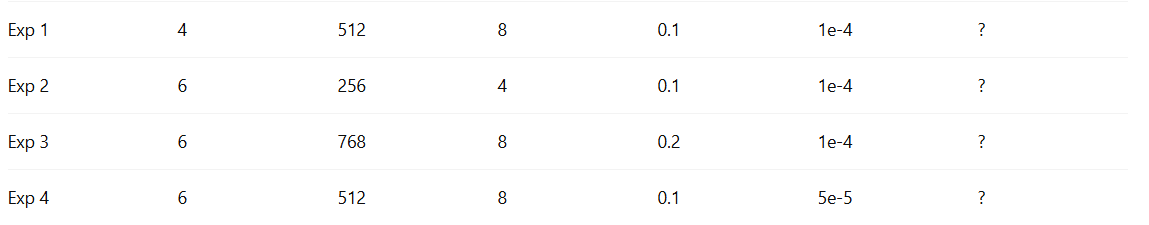

### **Exp1**

In [ ]:
!python train.py \
  --num_layers 4 \
  --d_model 256 \
  --nhead 4 \
  --dropout 0.1 \
  --lr 1e-4

usage:  [--experiment_name EXPERIMENT_NAME] [--num_classes NUM_CLASSES]
        [--hidden_dim HIDDEN_DIM] [--seed SEED]
        [--training_set_path TRAINING_SET_PATH]
        [--testing_set_path TESTING_SET_PATH]
        [--experimental_train_split EXPERIMENTAL_TRAIN_SPLIT]
        [--validation_set {from-file,split-from-train,none}]
        [--validation_set_size VALIDATION_SET_SIZE]
        [--validation_set_path VALIDATION_SET_PATH] [--epochs EPOCHS]
        [--lr LR] [--log_freq LOG_FREQ] [--save_checkpoints SAVE_CHECKPOINTS]
        [--scheduler_factor SCHEDULER_FACTOR]
        [--scheduler_patience SCHEDULER_PATIENCE]
        [--gaussian_mean GAUSSIAN_MEAN] [--gaussian_std GAUSSIAN_STD]
        [--plot_stats PLOT_STATS] [--plot_lr PLOT_LR]
: error: unrecognized arguments: --num_layers 4 --d_model 256 --nhead 4 --dropout 0.1
